In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier,ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,r2_score,mean_squared_error
from sklearn.tree import plot_tree
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv(r"D:\merged_flight_weather.csv")

In [3]:
def time_to_seconds(time_str):
    """Convert time in HHMMSS format to total seconds."""
    try:
        h, m, s = int(time_str[:2]), int(time_str[2:4]), int(time_str[4:])
        return h * 3600 + m * 60 + s
    except ValueError:
        return 0  # Handle invalid time strings

data['CRSDepTime'] = data['CRSDepTime'].astype(str).apply(time_to_seconds)

In [4]:
features = ['CRSArrTime', 'WindSpeedKmph', 'WindDirDegree', 'WeatherCode', 
            'precipMM', 'Visibilty', 'Pressure', 'Cloudcover', 'DewPointF', 
            'WindGustKmph', 'tempF', 'WindChillF', 'Humidity', 'Year', 
            'Quarter', 'Month', 'DayofMonth', 'CRSDepTime', 'DepDelayMinutes']

In [5]:
#data['IsDelayed'] = (data['ArrDelayMinutes'] >= 15).astype(int)
target ='ArrDel15'
#target = 'IsDelayed'

In [6]:
data = data.fillna(0)

In [7]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

In [8]:
X = data.drop(target, axis=1)
y = data[target]

In [9]:
X = data[features]
y = data[target]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [11]:
sm = SMOTE(random_state=42)

In [12]:
X_train, y_train = sm.fit_resample(X_train, y_train)

In [13]:
X_test, y_test = sm.fit_resample(X_test, y_test)

In [14]:
print(pd.Series(y_train).value_counts())

ArrDel15
0.0    1042387
1.0    1042387
Name: count, dtype: int64


In [15]:
print(pd.Series(y_test).value_counts())

ArrDel15
0.0    446851
1.0    446851
Name: count, dtype: int64


In [16]:
rfc = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)

In [17]:
rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [18]:
y_pred = rfc.predict(X_test)

In [19]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.88

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.93      0.89    446851
         1.0       0.92      0.83      0.88    446851

    accuracy                           0.88    893702
   macro avg       0.89      0.88      0.88    893702
weighted avg       0.89      0.88      0.88    893702



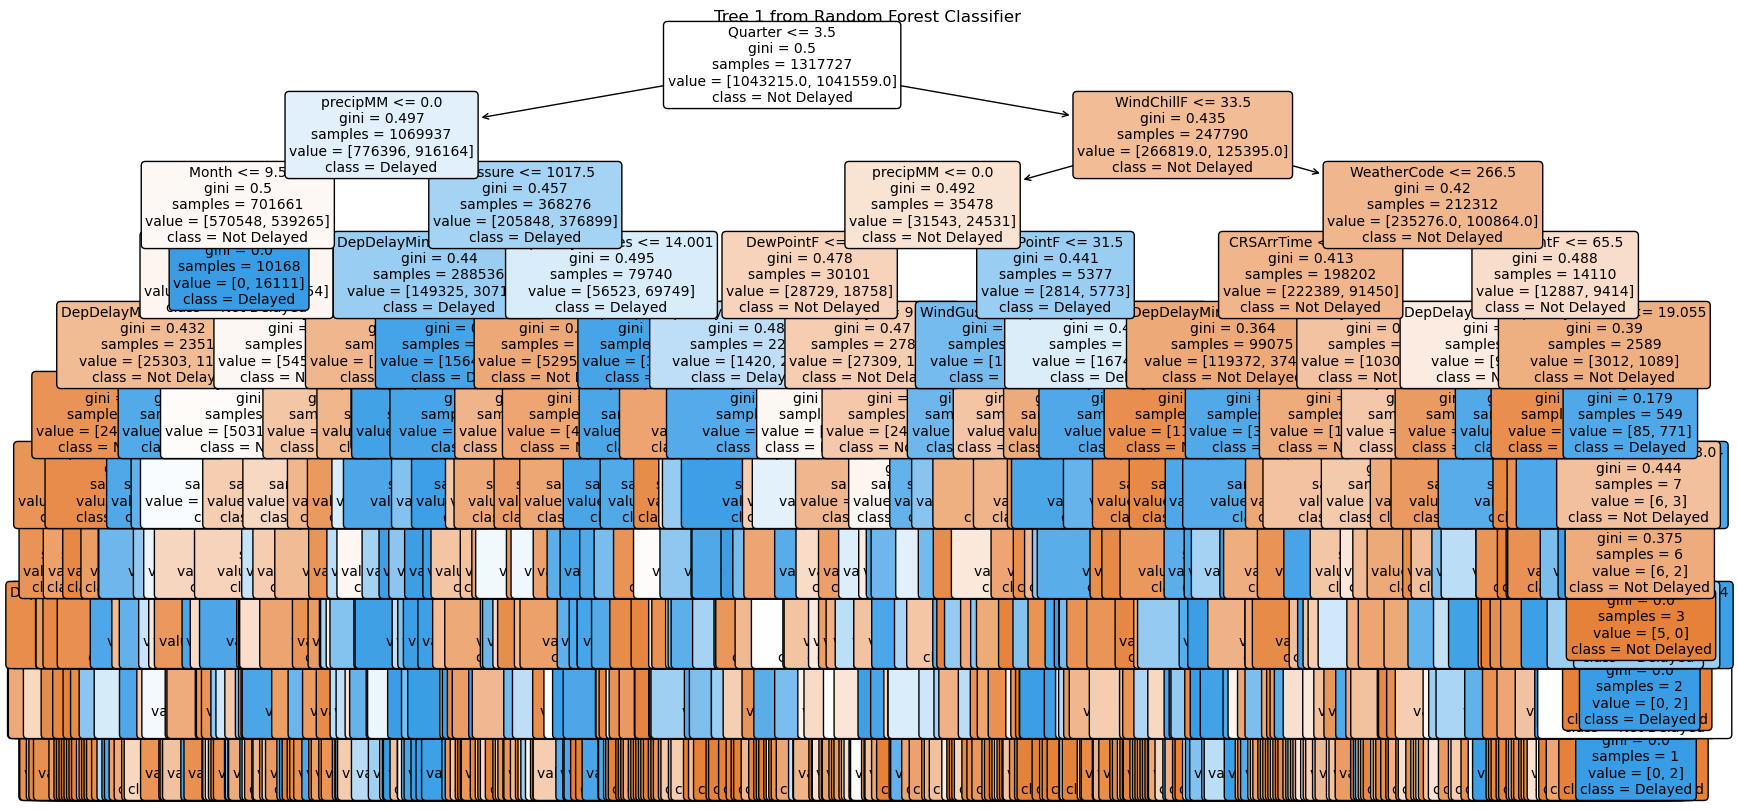

In [20]:
plt.figure(figsize=(20, 10))
tree_index = 0  # Index of the tree to plot
plot_tree(rfc.estimators_[tree_index], feature_names=features, class_names=['Not Delayed', 'Delayed'], 
          filled=True, rounded=True, fontsize=10)
plt.title(f"Tree {tree_index + 1} from Random Forest Classifier")
plt.show()